In [17]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d,gaussian_filter
import pickle
from skimage import io, filters
import glob
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import psutil
from brainsss import brain_utils
from scipy.ndimage import zoom

In [2]:
fly_num = 'fly_208'
moco_path = 'func_0/moco/functional_channel_2_moco.h5'
bg_path = 'func_0/background_subtraction/functional_channel_2_moco.h5'
warp_path = 'warp/functional_channel_2_moco_warp.h5'
blur_path = 'dff/functional_channel_2_moco_warp_blurred.h5'
hpf_path = 'dff/functional_channel_2_moco_warp_blurred_hpf.h5'
dff_path = 'dff/functional_channel_2_moco_warp_blurred_hpf_dff.h5'
timestamp_file = "warp/timestamps_warp.h5"
ts_file = "func_0/imaging"
temp_filter='temp_filter/functional_channel_2_moco_warp_blurred_hpf_dff_filtered.h5'
func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
moco_dir = os.path.join(func_path, moco_path)
bg_dir = os.path.join(func_path, bg_path)
warp_dir = os.path.join(func_path, warp_path)
blur_dir = os.path.join(func_path, blur_path)
hpf_dir = os.path.join(func_path, hpf_path)
dff_dir = os.path.join(func_path, dff_path)
og_ts_dir = os.path.join(func_path, ts_file)
ts_dir = os.path.join(func_path, timestamp_file)
filter_dir = os.path.join(func_path, temp_filter)

In [3]:
start=1500
end=1600

In [4]:
# %%time
# with h5py.File(moco_dir, 'r') as hf:
#         brain = hf['data']
#         brain = brain[...,start:end]
#         dimsb = np.shape(brain)
#         print(f"Data shape is {dimsb}")

In [5]:
# %%time
# with h5py.File(bg_dir, 'r') as bf:
#         bg = bf['data']
#         bg = bg[...,start:end]
#         dimsbg = np.shape(bg)
#         print(f"Data shape is {dimsbg}")

In [6]:
# %%time
# with h5py.File(warp_dir, 'r') as wf:
#         warp = wf['data']
#         warp = warp[...,start:end]
#         dimsw = np.shape(warp)
#         print(f"Data shape is {dimsw}")

In [7]:
# %%time
# with h5py.File(blur_dir, 'r') as df:
#         blur = df['data']
#         blur = blur[...,start:end]
#         dimsd = np.shape(blur)
#         print(f"Data shape is {dimsd}")

In [8]:
# %%time
# with h5py.File(hpf_dir, 'r') as pf:
#         filtered = pf['hpf']
#         filtered=filtered[...,start:end]
#         dimsf = np.shape(filtered)
#         print(f"Data shape is {dimsf}")

In [9]:
%%time
with h5py.File(dff_dir, 'r') as ff:
        dff = ff['data']
        dff=dff[...,start:end]
        dimsdf = np.shape(dff)
        print(f"Data shape is {dimsdf}")

Data shape is (314, 146, 91, 100)
CPU times: user 299 ms, sys: 9.74 s, total: 10 s
Wall time: 3min 52s


In [10]:
%%time
with h5py.File(filter_dir, 'r') as pf:
        tf = pf['brain'][:]
        tsf = pf['time_stamps'][:]
#         tf=tf[...,start:end]
#         tsf=tsf[...,start:end]
        dimstf = np.shape(tf)
        dimstsf = np.shape(tsf)
        print(f"Data shape is {dimstf}, timestamp shape is {dimstsf}")

Data shape is (314, 146, 91, 1030), timestamp shape is (314, 146, 91, 1030)
CPU times: user 173 µs, sys: 8.84 s, total: 8.84 s
Wall time: 8.84 s


In [11]:
# %%time
# with h5py.File(ts_dir, 'r') as tf:
#         ts = tf['data']
#         ts=ts[...,start:end]
#         dimsts=np.shape(ts)
#         print(f"Data shape is {dimsts}")

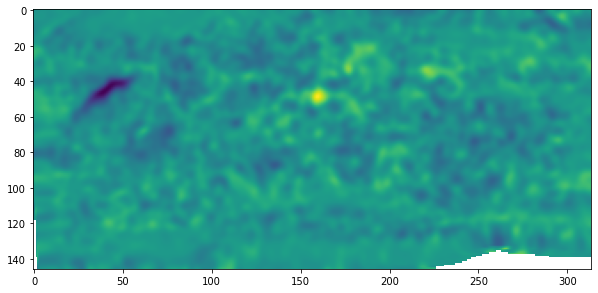

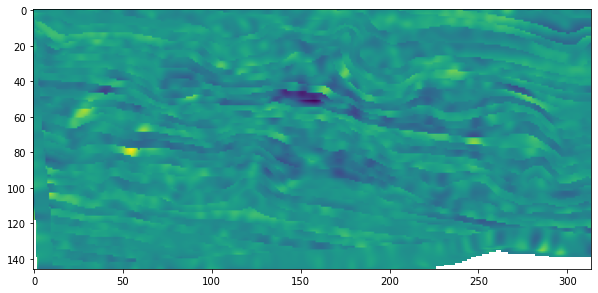

In [12]:
# plt.figure(figsize=(10,10))
# plt.imshow(brain[:,:,20,-1].T)
# plt.figure(figsize=(10,10))
# plt.imshow(bg[:,:,20,-1].T)
# plt.figure(figsize=(10,10))
# plt.imshow(warp[:,:,20,-1].T)
# plt.figure(figsize=(10,10))
# plt.imshow(blur[:,:,20,-1].T)
# plt.figure(figsize=(10,10))
# plt.imshow(filtered[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(dff[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(tf[:,:,20,100].T)
# plt.figure(figsize=(10,10))
# plt.imshow(ts[:,:,20,-1].T)

In [13]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape

(1256, 584, 363)

In [14]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')

(1256, 584, 363)


In [115]:
fixed = brainsss.load_fda_meanbrain()
brain=np.nan_to_num(tf)
print(f'fixed:{fixed.shape} brain:{brain.shape}')

fixed:(314, 146, 91) brain:(314, 146, 91, 1030)


In [116]:
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

In [117]:
masked=np.nanmax(masked, axis=-1)

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning:

All-NaN slice encountered



In [118]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

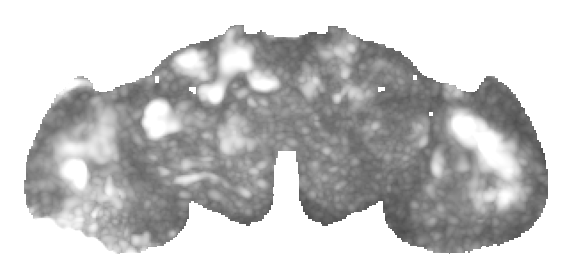

In [120]:
plt.figure(figsize=(10,10))
plt.imshow(masked[...,50].T, 'Greys_r', vmax=0.3, vmin=-0.03);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,'tf_brain.png'), dpi=300, bbox_inches='tight')